### Applying K Means Clusteting algorithm to cluster satellites into 'shells'
- Since our dataset is completely ready for ML models, we will now group similar satellites together
using k means clustering unsupervised model

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Important thorughout this project
%matplotlib inline


In [7]:
df = pd.read_csv('../data/model_ready/satellites_final.csv')

In [8]:
df.head()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_Q,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z
0,-2.005722,0.652233,1.309120,-1.121305,1.968277,-1.274152,-0.760235,0.162405,-0.053893,-0.015606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-2.382847,0.387491,1.309733,-1.085740,0.868905,-0.174813,5.155879,0.015232,-0.057616,-0.015606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-2.694500,2.110708,1.298236,0.215707,0.865634,0.809127,5.941114,0.015082,-0.057688,-0.015606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-2.651757,2.229186,1.294617,-0.584462,-0.652645,1.015582,5.960924,0.043338,-0.057305,-0.015606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.452026,-0.036020,0.345174,1.013130,1.761955,-1.726322,-0.818384,0.248900,-0.018401,-0.015606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Import necessary libraries

In [9]:
from sklearn.cluster import KMeans

In [10]:
# Create a model (we will use a random value for K), with a random state as 101
model = KMeans(n_clusters=5, random_state=101)

In [11]:
# Train and test the model
cluster_labels = model.fit_predict(df)

In [12]:
# predicted cluster label for each satellite
cluster_labels

array([4, 4, 4, ..., 1, 2, 2], shape=(11990,), dtype=int32)

In [13]:
# Make a seperate column
df['CLUSTER'] = cluster_labels

In [14]:
# Let's find the occurence of each cluster
df['CLUSTER'].value_counts().sort_values()

CLUSTER
3      34
4     602
1    1069
0    4417
2    5868
Name: count, dtype: int64

---
#### The question is, how do we even interprete this, as we dont even know what that 0, 1 or any other cluster actually is..

In [48]:
df.corr(numeric_only=True)['CLUSTER'].sort_values()

ARG_OF_PERICENTER   -0.739352
MEAN_MOTION_DOT     -0.095562
BSTAR               -0.056790
SAT_TYPE_X          -0.027415
SAT_TYPE_U          -0.027213
SAT_TYPE_W          -0.025688
SAT_TYPE_S          -0.025531
SAT_TYPE_P          -0.024408
SAT_TYPE_Q          -0.023913
SAT_TYPE_N          -0.023422
SAT_TYPE_R          -0.021627
SAT_TYPE_V          -0.021004
SAT_TYPE_Y          -0.020960
SAT_TYPE_M          -0.018482
SAT_TYPE_L          -0.014735
SAT_TYPE_H          -0.012295
MEAN_MOTION         -0.011003
ORBITAL_SPEED       -0.008919
SAT_TYPE_K          -0.008906
SAT_TYPE_J          -0.008739
MEAN_MOTION_DDOT    -0.007874
SAT_TYPE_G          -0.007391
SAT_TYPE_T          -0.007036
PERIGEE             -0.006408
SAT_TYPE_Z          -0.001563
ORBIT_PERIOD_SEC     0.004734
ORBIT_HEIGHT         0.005781
SEMI_MAJOR_AXIS      0.005781
SAT_TYPE_F           0.007236
SAT_TYPE_E           0.010986
SAT_TYPE_D           0.015713
APOGEE               0.017557
SAT_TYPE_C           0.020649
RA_OF_ASC_

- Let's plot the above thing

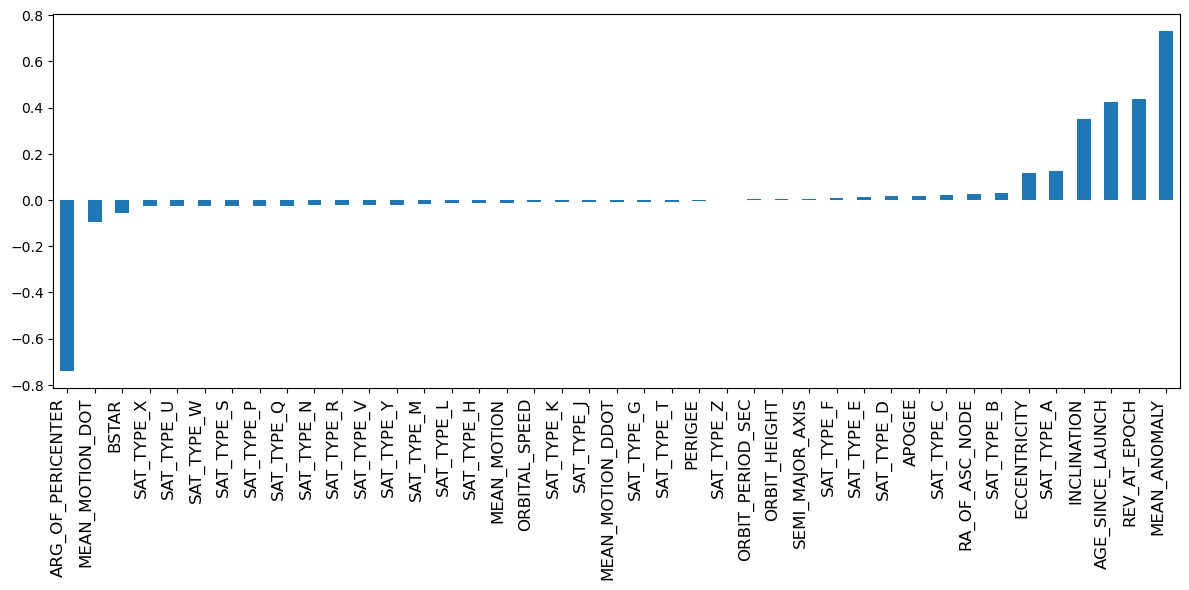

In [51]:
plt.figure(figsize=(12, 6))
df.corr(numeric_only=True)['CLUSTER'].sort_values()[:-1].plot(kind='bar')

plt.xticks(rotation=90, ha = 'right', fontsize = 12)
plt.tight_layout();

#### Interpreting the results for K = 5

- Let's consider the features having the most association with the cluster (both positive and negative)
- The featues most correlated are :
- ARG_OF_.., MEAN_MOTION_DOT, INCLINATION, AGE_SINCE_LAUNCH, REV_AT_EPOCH, MEAN_ANOMALY

In [52]:
most_corr_features = ['ARG_OF_PERICENTER', 'MEAN_MOTION_DOT', 'INCLINATION', 
                     'AGE_SINCE_LAUNCH', 'REV_AT_EPOCH', 'MEAN_ANOMALY'] 

In [53]:
grouped = df.groupby('CLUSTER')[most_corr_features].agg(['mean'])
grouped

,ARG_OF_PERICENTER,MEAN_MOTION_DOT,INCLINATION,AGE_SINCE_LAUNCH,REV_AT_EPOCH,MEAN_ANOMALY
,mean,mean,mean,mean,mean,mean
CLUSTER,,,,,,
0,1.149358,0.148446,-0.462692,-0.298134,-0.328875,-1.138811
1,-0.443167,-0.057922,0.973044,0.350991,0.331155,0.433233
2,-0.764246,-0.098656,0.030568,-0.136978,-0.103060,0.759722
3,-0.841592,-0.033602,0.327187,2.234044,2.426906,0.857553
4,-0.149100,-0.022775,1.350551,2.773218,2.692492,0.132554


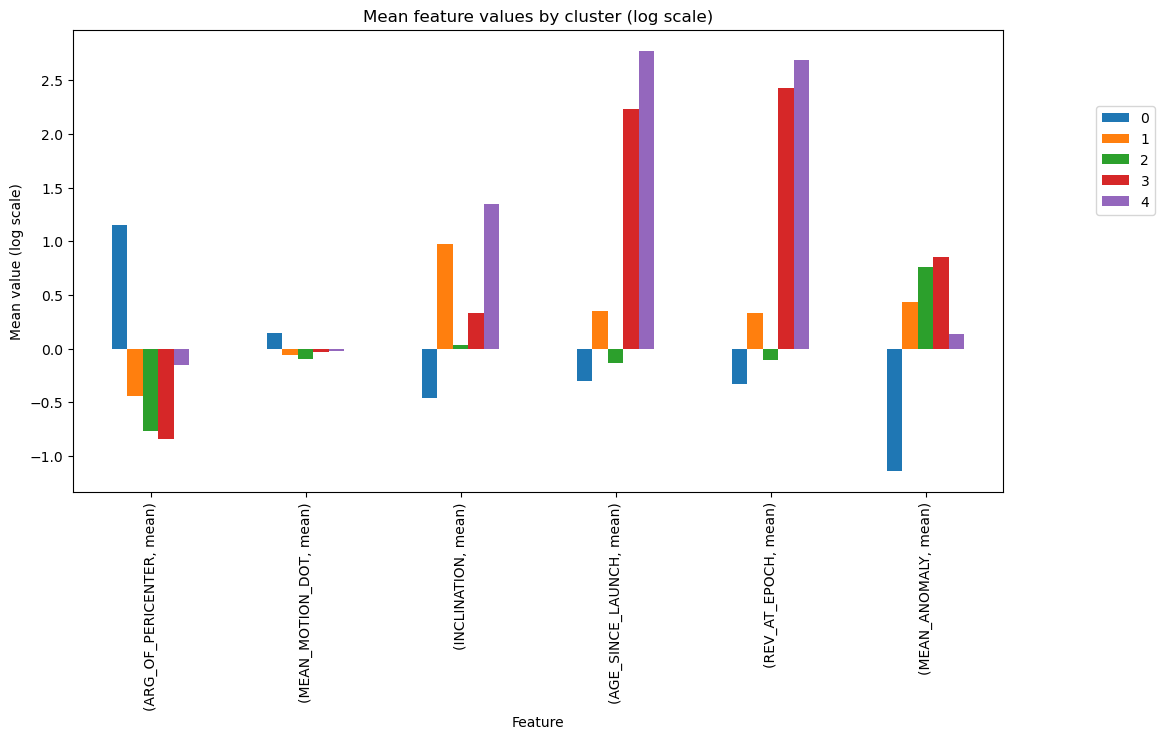

In [57]:
grouped.T.plot(kind='bar', figsize=(12,6)) 
plt.title("Mean feature values by cluster (log scale)")
plt.ylabel("Mean value (log scale)")
plt.xlabel("Feature")
plt.legend(loc=[1.1, 0.6])
plt.show()


- Physical meaning: 

| Cluster | Main Characteristic                             | Possible Satellite Type                     |
| ------- | ----------------------------------------------- | ------------------------------------------- |
| 0       | Newer, low-inclination, similar orientation     | Recently launched LEO constellations        |
| 1       | Mid-age, polar inclination                      | Earth-observation / reconnaissance          |
| 2       | Average across features                         | Transitional group                          |
| 3       | Old, low-moderate inclination, many revolutions | Aging operational satellites                |
| 4       | Very old, high-inclination                      | Polar / scientific or navigation satellites |
